Minimum Edit Distance Calculation

In [9]:
def min_edit_dis(s1,s2):
    n=len(s1)
    m=len(s2)

    dp=[[0 for _ in range(m+1)] for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0]=i
    for j in range(m+1):
        dp[0][j]=j

    for i in range(1,n+1):
        for j in range(1,m+1):
            if s1[i-1]==s2[j-1]:
                cost=0
            else:
                cost=2

            dp[i][j]=min(
                dp[i-1][j]+1,
                dp[i][j-1]+1,
                dp[i-1][j-1]+cost  )
    return dp,dp[n][m]

def sim_per(d,len1,len2):
    max_len=max(len1,len2)
    sp=((max_len-d)/max_len)*100
    return sp

s1=input("Enter First Text: ")
s2=input("Enter Second Text: ")

dp_table,d=min_edit_dis(s1,s2)
sp=sim_per(d,len(s1),len(s2))

print("Minimum Edit Distance:",d)
print("Similarity Percentage:",sp,"%")
print("\nEdit Distance Table:\n")
for i in dp_table:
    print(i)

Enter First Text: EXECUTION
Enter Second Text: INTENTION
Minimum Edit Distance: 8
Similarity Percentage: 11.11111111111111 %

Edit Distance Table:

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[1, 2, 3, 4, 3, 4, 5, 6, 7, 8]
[2, 3, 4, 5, 4, 5, 6, 7, 8, 9]
[3, 4, 5, 6, 5, 6, 7, 8, 9, 10]
[4, 5, 6, 7, 6, 7, 8, 9, 10, 11]
[5, 6, 7, 8, 7, 8, 9, 10, 11, 12]
[6, 7, 8, 7, 8, 9, 8, 9, 10, 11]
[7, 6, 7, 8, 9, 10, 9, 8, 9, 10]
[8, 7, 8, 9, 10, 11, 10, 9, 8, 9]
[9, 8, 7, 8, 9, 10, 11, 10, 9, 8]


Fake News Detection using Naive Biyas Algorithm

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
import re
import nltk
import string
import pandas as pd
import numpy as np

from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_curve,auc,classification_report
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
path="/content/drive/MyDrive/Nlp_Dataset.csv"
df=pd.read_csv(path,encoding='latin1')
df.head(5)

,News_Headline,Link_Of_News,Source,Stated_On,Date,Label
0,Says Osama bin Laden endorsed Joe Biden,https://www.politifact.com/factchecks/2020/jun...,Donald Trump Jr.,"June 18, 2020","June 19, 2020",FALSE
1,CNN aired a video of a toddler running away fr...,https://www.politifact.com/factchecks/2020/jun...,Donald Trump,"June 18, 2020","June 19, 2020",pants-fire
2,Says Tim Tebow kneeled in protest of abortion...,https://www.politifact.com/factchecks/2020/jun...,Facebook posts,"June 12, 2020","June 19, 2020",FALSE
3,Even so-called moderate Democrats like Joe Bi...,https://www.politifact.com/factchecks/2020/jun...,Paul Junge,"June 10, 2020","June 19, 2020",barely-true
4,"""Our health department, our city and our count...",https://www.politifact.com/factchecks/2020/jun...,Jeanette Kowalik,"June 14, 2020","June 18, 2020",TRUE


In [4]:
df.columns

Index(['News_Headline', 'Link_Of_News', 'Source', 'Stated_On', 'Date',
       'Label'],
      dtype='object')

In [5]:
noOfNull=df.isnull().sum()
print(noOfNull)

News_Headline    0
Link_Of_News     0
Source           0
Stated_On        0
Date             0
Label            0
dtype: int64


In [6]:
df.drop(['Link_Of_News','Source','Stated_On','Date'],axis=1,inplace=True,errors='ignore')

In [7]:
df

,News_Headline,Label
0,Says Osama bin Laden endorsed Joe Biden,FALSE
1,CNN aired a video of a toddler running away fr...,pants-fire
2,Says Tim Tebow kneeled in protest of abortion...,FALSE
3,Even so-called moderate Democrats like Joe Bi...,barely-true
4,"""Our health department, our city and our count...",TRUE
...,...,...
9955,Says the Obama administration plans to reduce ...,barely-true
9956,"The Foreign Intelligence Surveillance Court ""i...",pants-fire
9957,"""In the past four years, (the U.S. Senate) has...",mostly-true
9958,"On immigration reform, Marco Rubio ""all along ...",barely-true


In [8]:
df['Label'].value_counts()

,count
Label,
FALSE,2273
barely-true,1737
mostly-true,1722
half-true,1685
pants-fire,1402
TRUE,1036
full-flop,70
half-flip,27
no-flip,8


In [9]:
df["Label"]=df["Label"].str.lower().str.strip()

true_labels=["true","mostly-true","half-true"]

df["Binary_Label"]=df["Label"].apply(lambda x: "TRUE" if x in true_labels else "FALSE")

print(df["Binary_Label"].value_counts())

Binary_Label
FALSE    5517
TRUE     4443
Name: count, dtype: int64


In [10]:
df["clean"]=df["News_Headline"].str.lower()
df[["News_Headline","clean"]].head()

,News_Headline,clean
0,Says Osama bin Laden endorsed Joe Biden,says osama bin laden endorsed joe biden
1,CNN aired a video of a toddler running away fr...,cnn aired a video of a toddler running away fr...
2,Says Tim Tebow kneeled in protest of abortion...,says tim tebow kneeled in protest of abortion...
3,Even so-called moderate Democrats like Joe Bi...,even so-called moderate democrats like joe bi...
4,"""Our health department, our city and our count...","""our health department, our city and our count..."


In [11]:
df["clean"]=df["clean"].str.replace(r"[^\w\s]","",regex=True)

In [13]:
nltk.download('punkt_tab')
df["tokens"]=df["clean"].apply(word_tokenize)
df

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,News_Headline,Label,Binary_Label,clean,tokens
0,Says Osama bin Laden endorsed Joe Biden,false,FALSE,says osama bin laden endorsed joe biden,"[says, osama, bin, laden, endorsed, joe, biden]"
1,CNN aired a video of a toddler running away fr...,pants-fire,FALSE,cnn aired a video of a toddler running away fr...,"[cnn, aired, a, video, of, a, toddler, running..."
2,Says Tim Tebow kneeled in protest of abortion...,false,FALSE,says tim tebow kneeled in protest of abortion ...,"[says, tim, tebow, kneeled, in, protest, of, a..."
3,Even so-called moderate Democrats like Joe Bi...,barely-true,FALSE,even socalled moderate democrats like joe bide...,"[even, socalled, moderate, democrats, like, jo..."
4,"""Our health department, our city and our count...",true,TRUE,our health department our city and our county ...,"[our, health, department, our, city, and, our,..."
...,...,...,...,...,...
9955,Says the Obama administration plans to reduce ...,barely-true,FALSE,says the obama administration plans to reduce ...,"[says, the, obama, administration, plans, to, ..."
9956,"The Foreign Intelligence Surveillance Court ""i...",pants-fire,FALSE,the foreign intelligence surveillance court is...,"[the, foreign, intelligence, surveillance, cou..."
9957,"""In the past four years, (the U.S. Senate) has...",mostly-true,TRUE,in the past four years the us senate has only ...,"[in, the, past, four, years, the, us, senate, ..."
9958,"On immigration reform, Marco Rubio ""all along ...",barely-true,FALSE,on immigration reform marco rubio all along ha...,"[on, immigration, reform, marco, rubio, all, a..."


In [17]:
def remove_stopwords_nltk(tokens):
    return [w for w in tokens if w not in stop_words]
df["tokens_no_stopwords"]=df["tokens"].apply(remove_stopwords_nltk)

In [20]:
def lemmatize_tokens_nltk(tokens):
    return [lemmatizer.lemmatize(w) for w in tokens]

df["lemmatized"]=df["tokens_no_stopwords"].apply(lemmatize_tokens_nltk)
df["final_text"]=df["lemmatized"].apply(lambda x: " ".join(x))

In [21]:
x=df["final_text"]
y=df["Binary_Label"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
len(x_train),len(x_test)

(6972, 2988)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_df=0.9,min_df=3)
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

In [25]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB(alpha=1.0)

model.fit(x_train_tfidf,y_train)

y_pred=model.predict(x_test_tfidf)

In [28]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred,average="macro"))
print("Recall:",recall_score(y_test,y_pred,average="macro"))
print("F1 Score:",f1_score(y_test,y_pred,average="macro"))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.6569611780455153
Precision: 0.6508084731975363
Recall: 0.6487994190583266
F1 Score: 0.6494633562907919

Confusion Matrix:
 [[1200  479]
 [ 546  763]]

Classification Report:
               precision    recall  f1-score   support

       FALSE       0.69      0.71      0.70      1679
        TRUE       0.61      0.58      0.60      1309

    accuracy                           0.66      2988
   macro avg       0.65      0.65      0.65      2988
weighted avg       0.66      0.66      0.66      2988



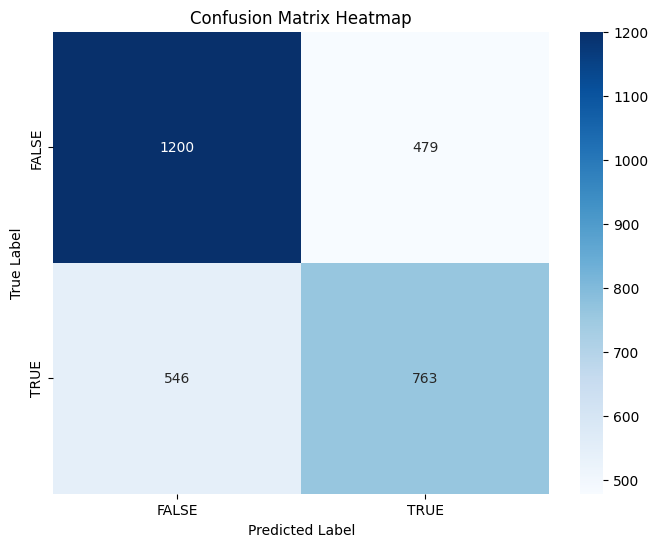

In [29]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['FALSE','TRUE'],yticklabels=['FALSE','TRUE'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

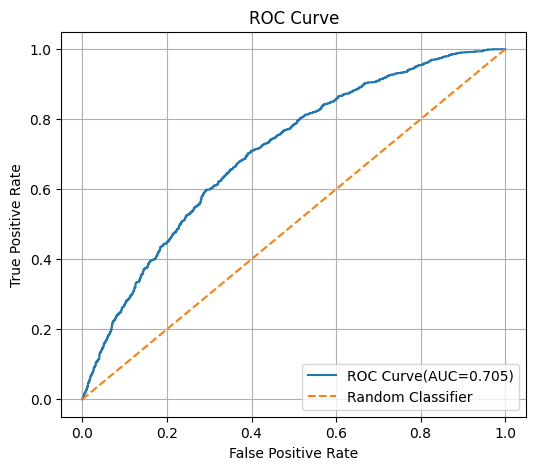

In [30]:
y_prob=model.predict_proba(x_test_tfidf)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob,pos_label="TRUE")
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"ROC Curve(AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
